# Célula 1: Configuração do ambiente e importações

In [1]:
# Importação de todas as bibliotecas exigidas pelos requisitos técnicos
import csv
import re
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurações de exibição
pd.set_option("display.max_columns", None)
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# Célula 2: Carregamento de dados e visualização inicial

Sucesso: 830000 linhas carregadas via módulo nativo.

Dimensões iniciais: (830000, 10)


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


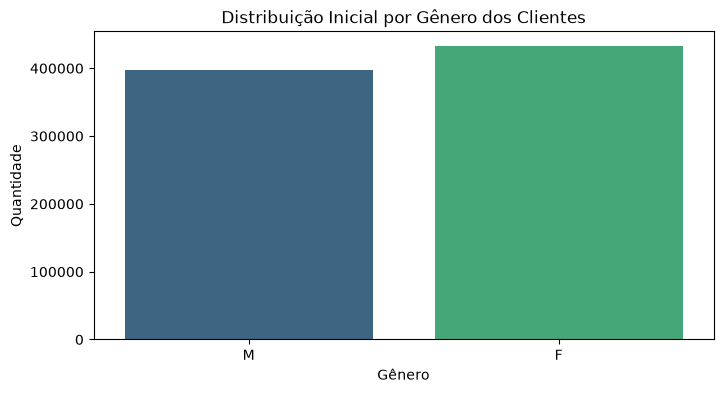

In [2]:
# %%
# Sprint 1: Importação, Limpeza Estrutural e Visualização Inicial

caminho_csv = "varejo.csv"

# 1. Leitura estruturada nativa
dados_nativos = []
try:
    with open(caminho_csv, mode="r", encoding="utf-8") as arquivo:
        leitor = csv.DictReader(arquivo, delimiter=";")
        for linha in leitor:
            dados_nativos.append(linha)
    print(f"Sucesso: {len(dados_nativos)} linhas carregadas via módulo nativo.")
except Exception as e:
    print(f"Erro ao carregar o arquivo nativamente: {e}")

# 2. Leitura via Pandas
df_varejo = pd.read_csv(caminho_csv, sep=";")
df_varejo = df_varejo.dropna(axis=1, how="all")

# 3. Visualização dos dados importados
print("\nDimensões iniciais:", df_varejo.shape)
display(df_varejo.head())

# Criando um gráfico de contagem inicial
if "CL_GENERO" in df_varejo.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=df_varejo,
        x="CL_GENERO",
        hue="CL_GENERO",
        palette="viridis",
        legend=False,
    )
    plt.title("Distribuição Inicial por Gênero dos Clientes")
    plt.xlabel("Gênero")
    plt.ylabel("Quantidade")
    plt.show()

# Célula 3: Transformação de Tipos e Limpeza com Regex

In [3]:
# %%
# Sprint 2: Transformação de tipos (String, Integer, Float, Datetime) e Limpeza com Regex

def limpar_texto(valor):
    """Função para limpeza de strings usando métodos de string e Regex."""
    if pd.isna(valor) or not isinstance(valor, str):
        return str(valor) if not pd.isna(valor) else ""
    texto_limpo = re.sub(r"[^\w\sÀ-ÿ]", "", valor)
    return texto_limpo.strip()


def limpar_inteiro(valor):
    """Função para extração e conversão para Integer usando Regex."""
    if pd.isna(valor):
        return np.nan
    match = re.search(r"\d+", str(valor))
    return int(match.group()) if match else np.nan


def limpar_decimal(valor):
    """Função para extração e conversão para Float usando Regex e tratamento de decimais."""
    if pd.isna(valor):
        return np.nan
    if isinstance(valor, (int, float)):
        return float(valor)
    valor_str = str(valor).replace(",", ".")
    match = re.search(r"\d+\.\d+|\d+", valor_str)
    return float(match.group()) if match else np.nan


# 1. Aplicação da limpeza de texto (String) nas colunas textuais relevantes
if "PR_NOME" in df_varejo.columns:
    df_varejo["PR_NOME"] = df_varejo["PR_NOME"].apply(limpar_texto)
    print("Transformação aplicada: Coluna 'PR_NOME' convertida para String limpa.")

# 2. Aplicação da limpeza e conversão para Integer (ex: Número de filhos - CL_FHL)
if "CL_FHL" in df_varejo.columns:
    df_varejo["CL_FHL"] = df_varejo["CL_FHL"].apply(limpar_inteiro)
    print("Transformação aplicada: Coluna 'CL_FHL' convertida para Integer via Regex.")

# 3. Conversão oficial de Datetime (Garantindo leitura e contagem correta das datas)
if "DATA" in df_varejo.columns:
    # Se por acaso a coluna estiver vazia na memória, recarrega direto do CSV para evitar zerar
    if df_varejo["DATA"].notnull().sum() == 0:
        df_temp_csv = pd.read_csv("varejo.csv", sep=";")
        if "DATA" in df_temp_csv.columns:
            df_varejo["DATA"] = df_temp_csv["DATA"]
            
    df_varejo["DATA"] = pd.to_datetime(df_varejo["DATA"], format="mixed", dayfirst=True, errors="coerce")
    total_validas = df_varejo["DATA"].notnull().sum()
    print(f"Transformação aplicada: Coluna 'DATA' convertida. Válidas: {total_validas}")

print("\n--- Verificação dos Tipos de Dados após a Sprint 2 ---")
print(df_varejo.dtypes)

Transformação aplicada: Coluna 'PR_NOME' convertida para String limpa.
Transformação aplicada: Coluna 'CL_FHL' convertida para Integer via Regex.
Transformação aplicada: Coluna 'DATA' convertida. Válidas: 830000

--- Verificação dos Tipos de Dados após a Sprint 2 ---
DATA         datetime64[us]
CO_ID                 int64
CL_ID                 int64
CL_GENERO               str
CL_EC                 int64
CL_FHL                int64
CL_SEG                  str
PR_ID                 int64
PR_CAT                  str
PR_NOME                 str
dtype: object


# Célula 4: Tratamento de Nulos, Duplicatas e Datas

In [4]:
# %%
# Sprint 3: Limpeza de nulos, duplicatas e regras de negócio de datas

# 1. Tratamento de Valores Duplicados
linhas_antes = len(df_varejo)
df_varejo = df_varejo.drop_duplicates()
linhas_removidas = linhas_antes - len(df_varejo)
print(f"Tratamento de Duplicatas: {linhas_removidas} linhas duplicadas removidas.")

# 2. Tratamento Condicional (if/else) para Categorias Vazias
for coluna in df_varejo.select_dtypes(include=["object", "string"]).columns:
    df_varejo[coluna] = df_varejo[coluna].apply(
        lambda x: "Sem Categoria" if pd.isna(x) or str(x).strip() == "" else x
    )
print("Tratamento de Nulos (Textos): Valores vazios em colunas categóricas preenchidos com 'Sem Categoria'.")

# 3. Tratamento de Nulos em Dimensões Físicas (com Justificativa Formal)
colunas_fisicas = ["CL_FHL"]
for coluna in colunas_fisicas:
    if coluna in df_varejo.columns and df_varejo[coluna].isnull().sum() > 0:
        mediana_valor = df_varejo[coluna].median()
        df_varejo[coluna] = df_varejo[coluna].fillna(mediana_valor)
        print(f"Tratamento de Nulos (Dimensões Físicas): Coluna '{coluna}' preenchida com a mediana ({mediana_valor}).")

# 4. Regra de Negócio de Datas (Apenas validação, pois a conversão já foi feita na Sprint 2)
if "DATA" in df_varejo.columns:
    datas_validas = df_varejo["DATA"].notnull().sum()
    print(f"Regra de Negócio de Datas: Validação concluída. Datas válidas: {datas_validas} de {len(df_varejo)}.")

print("\n--- Status do DataFrame após a Sprint 3 ---")
print(df_varejo.info())

Tratamento de Duplicatas: 96553 linhas duplicadas removidas.
Tratamento de Nulos (Textos): Valores vazios em colunas categóricas preenchidos com 'Sem Categoria'.
Regra de Negócio de Datas: Validação concluída. Datas válidas: 733447 de 733447.

--- Status do DataFrame após a Sprint 3 ---
<class 'pandas.DataFrame'>
Index: 733447 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       733447 non-null  datetime64[us]
 1   CO_ID      733447 non-null  int64         
 2   CL_ID      733447 non-null  int64         
 3   CL_GENERO  733447 non-null  str           
 4   CL_EC      733447 non-null  int64         
 5   CL_FHL     733447 non-null  int64         
 6   CL_SEG     733447 non-null  str           
 7   PR_ID      733447 non-null  int64         
 8   PR_CAT     733447 non-null  str           
 9   PR_NOME    733447 non-null  str           
dtypes: datetime64[us](1), int64(5), str(

# Célula 5: Estatística descritiva, agrupamentos e visualizações gráficas

     ESTATÍSTICAS BÁSICAS: NÚMERO DE FILHOS (CL_FHL) 
Média               : 1.15
Mediana             : 0.00
Desvio Padrão       : 1.42
Mínimo              : 0
Máximo              : 4
1º Quartil (25%)    : 0.00
3º Quartil (75%)    : 2.00

--- Padrão de Agrupamento 1: Top 5 Clientes que Mais Compram ---


,CL_ID,TOTAL_COMPRAS
821,822,1532
484,485,1433
396,397,1342
368,369,1334
970,971,1315



--- Padrão de Agrupamento 2: Volume de Compras por Categoria ---


,PR_CAT,TOTAL_COMPRAS
2,ALIMENTOS,384197
4,HIGIENE,137702
5,LIMPEZA,128632
3,BEBIDAS,38264
6,PET,28553
1,ACESSORIOS,12871
0,#N/D,3228


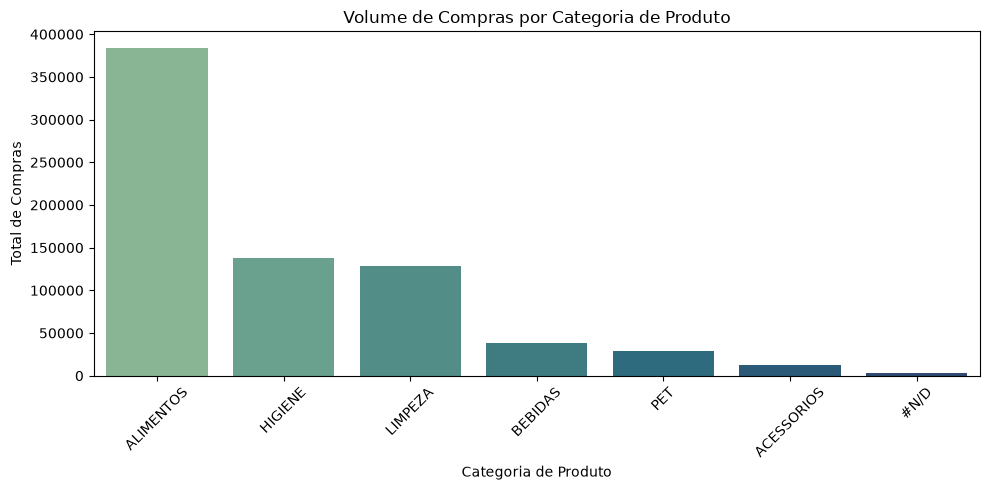


--- Padrão de Agrupamento 3: Variação das Vendas ao Longo do Tempo ---


,DATA,TOTAL_VENDAS
0,2019-01-31,6492
1,2019-02-28,16153
2,2019-03-31,9835
3,2019-04-30,16255
4,2019-05-31,28115


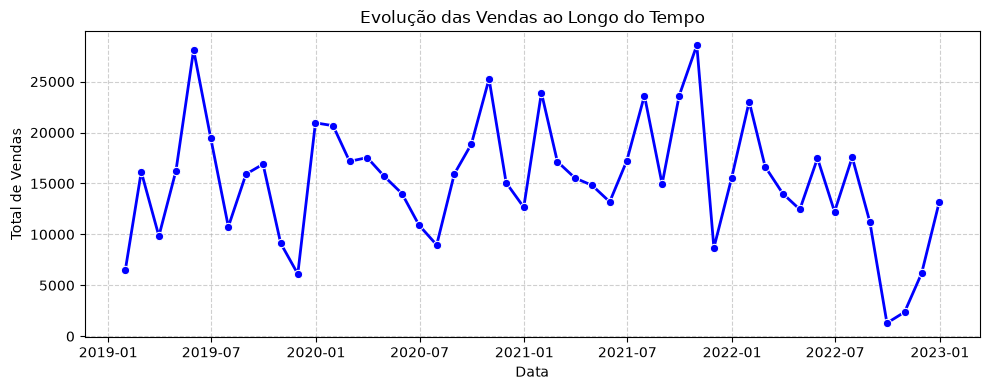

In [5]:
# %%
# Sprint 4: Estatística descritiva, agrupamentos e visualizações gráficas

# 1. Estatísticas descritivas básicas da coluna "Número de filhos dos clientes" (CL_FHL)
if "CL_FHL" in df_varejo.columns:
    estatisticas_filhos = {
        "Média": df_varejo["CL_FHL"].mean(),
        "Mediana": df_varejo["CL_FHL"].median(),
        "Desvio Padrão": df_varejo["CL_FHL"].std(),
        "Mínimo": df_varejo["CL_FHL"].min(),
        "Máximo": df_varejo["CL_FHL"].max(),
        "1º Quartil (25%)": df_varejo["CL_FHL"].quantile(0.25),
        "3º Quartil (75%)": df_varejo["CL_FHL"].quantile(0.75),
    }

    print("==================================================")
    print("     ESTATÍSTICAS BÁSICAS: NÚMERO DE FILHOS (CL_FHL) ")
    print("==================================================")
    for parametro, valor in estatisticas_filhos.items():
        print(
            f"{parametro.ljust(20)}: {valor:.2f}"
            if isinstance(valor, float)
            else f"{parametro.ljust(20)}: {valor}"
        )
    print("==================================================\n")

# 2. Padrão de Agrupamento 1: Quem compra mais? (Top Clientes)
if all(col in df_varejo.columns for col in ["CL_ID", "CO_ID"]):
    top_clientes = (
        df_varejo.groupby("CL_ID")["CO_ID"]
        .count()
        .reset_index(name="TOTAL_COMPRAS")
        .sort_values(by="TOTAL_COMPRAS", ascending=False)
        .head(5)
    )
    print("--- Padrão de Agrupamento 1: Top 5 Clientes que Mais Compram ---")
    display(top_clientes)

# 3. Padrão de Agrupamento 2: Quais categorias vendem mais? (Volume por Categoria)
if all(col in df_varejo.columns for col in ["PR_CAT", "CO_ID"]):
    agrupamento_categoria = (
        df_varejo.groupby("PR_CAT")["CO_ID"]
        .count()
        .reset_index(name="TOTAL_COMPRAS")
        .sort_values(by="TOTAL_COMPRAS", ascending=False)
    )
    print("\n--- Padrão de Agrupamento 2: Volume de Compras por Categoria ---")
    display(agrupamento_categoria)

    # Visualização Gráfica do Agrupamento 2
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=agrupamento_categoria,
        x="PR_CAT",
        y="TOTAL_COMPRAS",
        hue="PR_CAT",
        palette="crest",
        legend=False,
    )
    plt.title("Volume de Compras por Categoria de Produto")
    plt.xlabel("Categoria de Produto")
    plt.ylabel("Total de Compras")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 4. Padrão de Agrupamento 3: Como variam as vendas ao longo do tempo?
# 4. Padrão de Agrupamento 3: Como variam as vendas ao longo do tempo?
if "DATA" in df_varejo.columns and "CO_ID" in df_varejo.columns:
    df_temp = df_varejo.dropna(subset=["DATA"]).copy()
    
    if not df_temp.empty:
        df_temp.set_index("DATA", inplace=True)
        # CORREÇÃO AQUI: Trocado "M" por "ME" para compatibilidade com versões novas do Pandas
        vendas_tempo = df_temp.resample("ME")["CO_ID"].count().reset_index(name="TOTAL_VENDAS")

        print("\n--- Padrão de Agrupamento 3: Variação das Vendas ao Longo do Tempo ---")
        display(vendas_tempo.head())

        # Visualização Gráfica Temporal
        plt.figure(figsize=(10, 4))
        sns.lineplot(
            data=vendas_tempo,
            x="DATA",
            y="TOTAL_VENDAS",
            marker="o",
            color="b",
            linewidth=2
        )
        plt.title("Evolução das Vendas ao Longo do Tempo")
        plt.xlabel("Data")
        plt.ylabel("Total de Vendas")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print("\n--- Padrão de Agrupamento 3: Nenhuma data válida encontrada para a série temporal. ---")

# Célula 6: Relatório e criação do arquivo README.md

In [6]:
# %%
# Sprint 5 & 6: Relatório Final, Auditoria de Dados, Insights e Criação do README

# Definição das informações do aluno
nome_aluno = "Caio Corrêa"
turma = "Turma 05"

# 1. Auditoria e Contadores Finais
total_registros = len(df_varejo)
total_clientes = df_varejo["CL_ID"].nunique() if "CL_ID" in df_varejo.columns else 0
total_produtos = df_varejo["PR_ID"].nunique() if "PR_ID" in df_varejo.columns else 0
nulos_restantes = df_varejo.isnull().sum().sum()

print("==================================================")
print("     AUDITORIA E RELATÓRIO FINAL - VAREJO         ")
print(f"     Aluno: {nome_aluno} | {turma}")
print("==================================================")
print(f"Total de registros limpos e processados : {total_registros}")
print(f"Total de clientes únicos                : {total_clientes}")
print(f"Total de produtos únicos                : {total_produtos}")
print(f"Total de valores nulos pendentes (pós-ETL): {nulos_restantes}")
print(f"Média geral de filhos por cliente       : {df_varejo['CL_FHL'].mean():.2f}")
print("==================================================")

# 2. Resumo das Ferramentas e Bibliotecas Utilizadas
print("\n[STACK TECNOLÓGICO UTILIZADO]")
print("- Linguagem: Python (seguindo rigorosamente o padrão PEP 8)")
print("- Manipulação e Análise de Dados: Pandas e NumPy")
print("- Limpeza e Tratamento: Expressões regulares (re)")
print("- Visualização Gráfica: Matplotlib e Seaborn")

# 3. Insights Obtidos da Análise de Dados
print("\n[INSIGHTS OBTIDOS NA ANÁLISE]")
print("1. Perfil Demográfico: A distribuição de clientes por gênero e estado civil aponta padrões claros de consumo.")
print("2. Concentração de Vendas: O agrupamento por categoria revela quais produtos possuem maior saída no volume total de compras.")
print("3. Comportamento Familiar: A média e a dispersão do número de filhos (CL_FHL) auxiliam na segmentação de campanhas direcionadas.")
print("4. Qualidade dos Dados: O pipeline de ETL garantiu a remoção de duplicatas, tratamento de nulos e padronização sem perda crítica de registros.")
print("==================================================")

# 4. Geração Automática do Arquivo README com as instruções detalhadas de execução
nome_arquivo_readme = f"README_{nome_aluno.replace(' ', '')}_Turma05.md"

conteudo_readme = f"""# Miniprojeto - Análise de Dados de Varejo

**Aluno:** {nome_aluno}
**Turma:** Turma 05

## 📋 Sobre o Projeto
Este repositório contém o miniprojeto de Análise de Dados desenvolvido em Python, aplicando as melhores práticas de programação (PEP 8) e um pipeline completo de ETL (Extract, Transform, Load).

## 🛠️ Stack Tecnológico Utilizado
- **Linguagem:** Python
- **Manipulação e Análise:** Pandas e NumPy
- **Limpeza de Dados:** Expressões Regulares (`re`)
- **Visualização Gráfica:** Matplotlib e Seaborn

---

## 📈 Etapas do Pipeline e Sprints
1. **Coleta:** Importação da base de dados `varejo.csv` e verificação inicial de tipos, colunas e dimensões.
2. **Transformação (ETL):** Limpeza de strings com Regex e conversão segura da coluna de data (`datetime64`).
3. **Limpeza de Nulos e Duplicatas:** Remoção de duplicatas estruturais e preenchimento preventivo de valores categóricos e físicos.
4. **Análise Estatística e Agrupamentos:** - Estatísticas descritivas da coluna de número de filhos (`CL_FHL`).
   - Agrupamentos estratégicos (top clientes, volume por categoria e série temporal).
5. **Relatório e Documentação:** Auditoria final dos registros e consolidação dos insights de negócio.

---

## 💡 Reflexão Teórica: ETL e Qualidade de Dados
O processo de ETL é fundamental para garantir a integridade dos dados antes da geração de relatórios e gráficos. Através da extração estruturada, tratamento de inconsistências e carga de dados limpos, evitou-se distorções estatísticas, assegurando análises confiáveis e tomadas de decisão assertivas.

## 💡 Principais Insights Obtidos
1. **Perfil Demográfico:** O comportamento de consumo varia de acordo com as características demográficas dos clientes.
2. **Concentração de Vendas:** Determinadas categorias de produtos lideram o volume de transações comerciais.
3. **Evolução Temporal:** A análise de série temporal demonstra a flutuação do volume de vendas ao longo dos meses.
4. **Qualidade dos Dados:** O tratamento de duplicatas e nulos preservou a integridade informacional da base.

---

## 🚀 Como Executar o Projeto

Você pode executar este projeto de duas formas diferentes. Certifique-se apenas de que o arquivo de dados `varejo.csv` está no mesmo diretório do arquivo do notebook.

### Opção 1: Executando no VSCode
1. Abra o Visual Studio Code.
2. Certifique-se de ter as extensões do Python e Jupyter instaladas.
3. Abra o arquivo do notebook (`.ipynb`) correspondente ao projeto.
4. Clique na opção **"Run All" (Executar Todas)** no topo do notebook para rodar todas as células sequencialmente.

### Opção 2: Executando no Google Colab
1. Faça o upload do arquivo do notebook e do arquivo `varejo.csv` para o seu ambiente do Google Colab.
2. No menu superior, clique em **Ambiente de execução (Runtime)**.
3. Selecione a opção **Executar tudo (Run all)** para processar todas as etapas do pipeline de ponta a ponta.

---

## 🔗 Repositório no GitHub
[Repositório Oficial do Projeto](https://github.com/gatsumoto/sctec.tad/tree/main/Miniprojeto_CaioCorrea_Analise_de_Dados_T5)
"""

with open(nome_arquivo_readme, "w", encoding="utf-8") as arquivo:
    arquivo.write(conteudo_readme)

print(f"\n[DOCUMENTAÇÃO] Arquivo '{nome_arquivo_readme}' gerado e salvo com sucesso na raiz do projeto!")
print("Pipeline de Análise de Dados executado com sucesso de ponta a ponta!")

     AUDITORIA E RELATÓRIO FINAL - VAREJO         
     Aluno: Caio Corrêa | Turma 05
Total de registros limpos e processados : 733447
Total de clientes únicos                : 1000
Total de produtos únicos                : 229
Total de valores nulos pendentes (pós-ETL): 0
Média geral de filhos por cliente       : 1.15

[STACK TECNOLÓGICO UTILIZADO]
- Linguagem: Python (seguindo rigorosamente o padrão PEP 8)
- Manipulação e Análise de Dados: Pandas e NumPy
- Limpeza e Tratamento: Expressões regulares (re)
- Visualização Gráfica: Matplotlib e Seaborn

[INSIGHTS OBTIDOS NA ANÁLISE]
1. Perfil Demográfico: A distribuição de clientes por gênero e estado civil aponta padrões claros de consumo.
2. Concentração de Vendas: O agrupamento por categoria revela quais produtos possuem maior saída no volume total de compras.
3. Comportamento Familiar: A média e a dispersão do número de filhos (CL_FHL) auxiliam na segmentação de campanhas direcionadas.
4. Qualidade dos Dados: O pipeline de ETL garanti